# Lab 5 · Diffusion FWI — Interactive Generation Notebook

**Goal:** Generate probabilistic subsurface velocity models from seismic observations using a pre-trained conditional diffusion model.

| What you’ll do | How |
|---|---|
| Explore seismic input data | Sample + source selector widgets |
| Inspect the ground-truth velocity model | Interactive visualisation |
| Load a pre-trained `DiffusionFWINet` | `physicsnemo.Module.from_checkpoint` |
| Run ensemble generation (CPU ~2 min, GPU seconds) | Zero-shot conditional sampling |
| Visualise predictions & uncertainty | Pre-generated results included |

> **No GPU required for visualisation.** Pre-generated outputs are bundled in `outputs_cond/`.

In [ ]:
# SPDX-FileCopyrightText: Copyright (c) 2023 - 2026 NVIDIA CORPORATION & AFFILIATES.
# SPDX-License-Identifier: Apache-2.0

## 1 · Setup

In [ ]:
import sys
from pathlib import Path
from functools import partial

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from einops import rearrange

from physicsnemo import Module
from physicsnemo.diffusion.utils import StackedRandomGenerator
from utils.preconditioning import edm_precond
from utils.diffusion import DiffusionAdapter, EDMStochasticSampler
from utils.nn import DiffusionFWINet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Imports OK  |  Device: {DEVICE}  |  PyTorch: {torch.__version__}')

## 2 · Configuration

Choose a sample, checkpoint, and generation settings using the widgets below.

In [13]:
CHECKPOINT_DIR = NOTEBOOK_DIR / 'checkpoints' / 'conditional'
OUTPUT_DIR     = NOTEBOOK_DIR / 'outputs_cond'

checkpoint_options = sorted([f.name for f in CHECKPOINT_DIR.glob('*.mdlus')]) or ['(none found)']
sample_options     = sorted([d.name for d in OUTPUT_DIR.iterdir() if d.is_dir() and d.name.startswith('sample_')])

w_checkpoint = widgets.Dropdown(
    options=checkpoint_options,
    description='Checkpoint:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
w_sample = widgets.Dropdown(
    options=sample_options,
    value=sample_options[0] if sample_options else None,
    description='Sample:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
w_sources = widgets.IntSlider(
    value=3, min=1, max=12, step=1,
    description='Sources shown:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
w_ensembles = widgets.IntSlider(
    value=4, min=1, max=16, step=1,
    description='Ensembles (live):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
display(widgets.VBox([
    widgets.HTML('<b>Model &amp; Data</b>'),
    w_checkpoint, w_sample,
    widgets.HTML('<b>Display &amp; Generation</b>'),
    w_sources, w_ensembles,
]))

## 3 · Load & Visualise Input Data

The seismic recordings ($v_x$, $v_z$) are the conditioning signal fed to the diffusion model.

In [14]:
def load_sample(name):
    return dict(np.load(OUTPUT_DIR / name / 'numpy' / 'data.npz', allow_pickle=True))

sample_data = load_sample(w_sample.value)
vx_np = sample_data['vx'][0]   # (nb_shots, T, W)
vz_np = sample_data['vz'][0]
print(f"Loaded '{w_sample.value}' — seismic shape: {vx_np.shape}  (shots × time × receivers)")

Loaded 'sample_0' — seismic shape: (5, 1000, 80)  (shots × time × receivers)


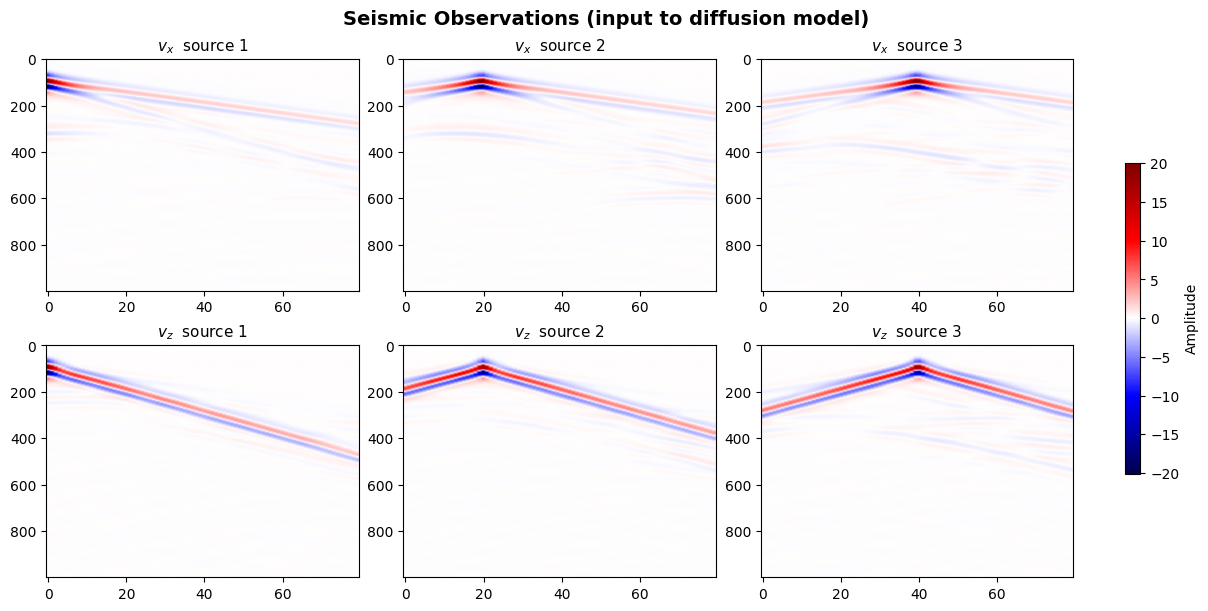

In [15]:
def plot_seismic(vx, vz, n_sources):
    n = min(n_sources, vx.shape[0])
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 6), constrained_layout=True)
    fig.suptitle('Seismic Observations (input to diffusion model)', fontsize=14, fontweight='bold')
    if n == 1: axes = axes[:, np.newaxis]
    vmax = max(np.abs(vx).max(), np.abs(vz).max()) * 0.8
    kw = dict(aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax)
    for i in range(n):
        im = axes[0, i].imshow(vx[i], **kw)
        axes[0, i].set_title(f'$v_x$  source {i+1}', fontsize=11)
        axes[1, i].imshow(vz[i], **kw)
        axes[1, i].set_title(f'$v_z$  source {i+1}', fontsize=11)
    plt.colorbar(im, ax=axes, label='Amplitude', shrink=0.6)
    plt.show()

plot_seismic(vx_np, vz_np, w_sources.value)

### Ground-Truth Velocity Model

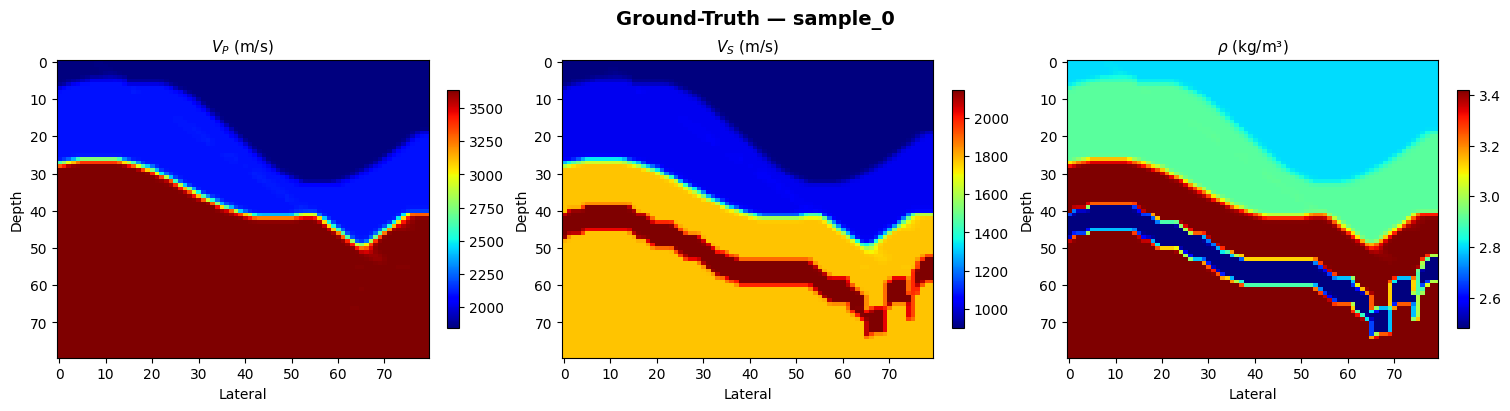

In [16]:
def plot_velocity_model(data, title='Velocity Model'):
    fields = [('vp_true', '$V_P$ (m/s)'), ('vs_true', '$V_S$ (m/s)'), ('rho_true', r'$\rho$ (kg/m³)')]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, (key, lbl) in zip(axes, fields):
        arr = data[key][0, 0]   # (batch=1, channel=1, H, W) -> (H, W)
        im = ax.imshow(arr, cmap='jet', aspect='auto', origin='upper')
        ax.set_title(lbl, fontsize=11)
        ax.set_xlabel('Lateral'); ax.set_ylabel('Depth')
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.show()

plot_velocity_model(sample_data, title=f'Ground-Truth — {w_sample.value}')

## 4 · Load Diffusion Model

In [ ]:
ckpt_path = CHECKPOINT_DIR / w_checkpoint.value
print(f'Loading: {ckpt_path}')

diffusion_net = Module.from_checkpoint(str(ckpt_path))
diffusion_net = diffusion_net.to(DEVICE).eval()
n_params = sum(p.numel() for p in diffusion_net.parameters())
print(f'✓ Loaded  |  {n_params:,} parameters  |  device: {DEVICE}')

adapter = DiffusionAdapter(diffusion_net, args_map=('x', 'sigma', {'y': 'y'}))
model_fn = partial(edm_precond, adapter, sigma_data=0.5)
# sigma_max=80 matches the training config (NOT the default 800)
sampler = EDMStochasticSampler(model=model_fn, num_steps=18, sigma_min=0.002, sigma_max=80.0)
print('✓ Sampler ready')

# Normalization stats used during training — needed to convert model output to physical units
STATS_MEAN = torch.tensor([3000.0, 1700.0, 2200.0])   # vp (m/s), vs (m/s), rho (kg/m³)
STATS_STD  = torch.tensor([ 800.0,  500.0,  300.0])

## 5 · Generate Predictions

**Pre-generated** loads bundled outputs instantly.  
**Live inference** runs the diffusion model (~2 min on CPU, seconds on GPU).

In [18]:
w_mode = widgets.ToggleButtons(
    options=['Pre-generated (instant)', 'Live inference'],
    description='Mode:',
    style={'description_width': '80px', 'button_width': '200px'},
)
display(w_mode)

ToggleButtons(description='Mode:', options=('Pre-generated (instant)', 'Live inference'), style=ToggleButtonsS…

In [ ]:
if w_mode.value == 'Pre-generated (instant)':
    print(f"Loading pre-generated predictions for '{w_sample.value}'...")
    pred = load_sample(w_sample.value)
    def _load_var(key, fallback):
        arr = torch.from_numpy(pred.get(key, pred[fallback][None])).float()
        # squeeze channel dim if shape is (N, 1, H, W)
        return arr.squeeze(1) if arr.ndim == 4 and arr.shape[1] == 1 else arr
    vp  = _load_var('vp_ensemble',  'vp_mean')
    vs  = _load_var('vs_ensemble',  'vs_mean')
    rho = _load_var('rho_ensemble', 'rho_mean')
    x_pred = torch.stack([vp, vs, rho], dim=1)  # (N, 3, H, W) — already in physical units
    print(f'✓ Loaded {x_pred.shape[0]} ensemble members, shape {tuple(x_pred.shape)}')
else:
    print(f'Running live inference ({w_ensembles.value} ensembles) on {DEVICE}...')
    vx_t = torch.from_numpy(sample_data['vx']).float().to(DEVICE)
    vz_t = torch.from_numpy(sample_data['vz']).float().to(DEVICE)
    y_cond = torch.cat([vx_t, vz_t], dim=1)           # (1, 2*shots, T, W_rec)
    N = w_ensembles.value
    H, W = sample_data['vp_true'].shape[-2], sample_data['vp_true'].shape[-1]

    rng = StackedRandomGenerator(DEVICE, list(range(N)))
    # Pure std-normal noise — sampler scales by sigma_max (80) internally
    x_init = rng.randn((N, 3, H, W), device=DEVICE)

    with torch.no_grad():
        x_norm = sampler(x_init, cond={'y': y_cond.expand(N, -1, -1, -1)}).cpu()

    # Denormalize from training-space to physical units
    std  = STATS_STD.view(1, 3, 1, 1)
    mean = STATS_MEAN.view(1, 3, 1, 1)
    x_pred = x_norm * std + mean   # (N, 3, H, W) in physical units

    print(f'✓ Generated {x_pred.shape[0]} ensemble members, shape {tuple(x_pred.shape)}')
    print(f'  vp range: [{x_pred[:,0].min():.0f}, {x_pred[:,0].max():.0f}] m/s')

## 6 · Predictions vs Ground Truth

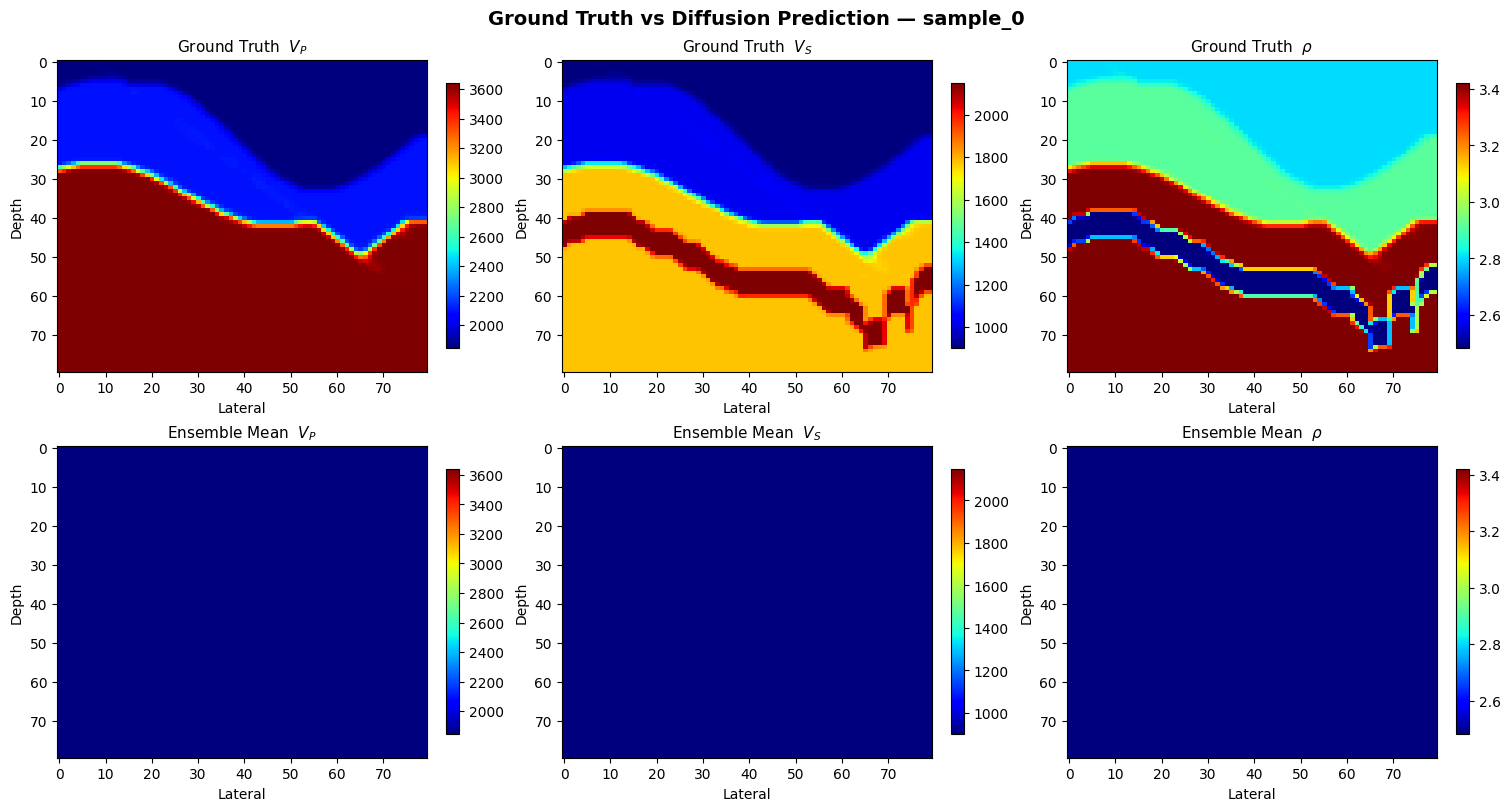

In [23]:
def plot_predictions(sample_data, x_pred, title=''):
    fields = [('vp_true', '$V_P$', 0), ('vs_true', '$V_S$', 1), ('rho_true', r'$\rho$', 2)]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    fig.suptitle(f'Ground Truth vs Diffusion Prediction — {title}', fontsize=14, fontweight='bold')
    for col, (key, lbl, idx) in enumerate(fields):
        gt   = sample_data[key][0, 0]       # (H, W)
        pred = x_pred[:, idx].mean(0).numpy()  # (H, W)
        kw = dict(cmap='jet', aspect='auto', origin='upper', vmin=gt.min(), vmax=gt.max())
        plt.colorbar(axes[0, col].imshow(gt, **kw), ax=axes[0, col], shrink=0.85)
        axes[0, col].set_title(f'Ground Truth  {lbl}', fontsize=11)
        plt.colorbar(axes[1, col].imshow(pred, **kw), ax=axes[1, col], shrink=0.85)
        axes[1, col].set_title(f'Ensemble Mean  {lbl}', fontsize=11)
        for ax in axes[:, col]:
            ax.set_xlabel('Lateral'); ax.set_ylabel('Depth')
    plt.show()

plot_predictions(sample_data, x_pred, title=w_sample.value)

## 7 · Ensemble Uncertainty

Variance across ensemble members highlights where the model is uncertain — typically at sharp geological boundaries.

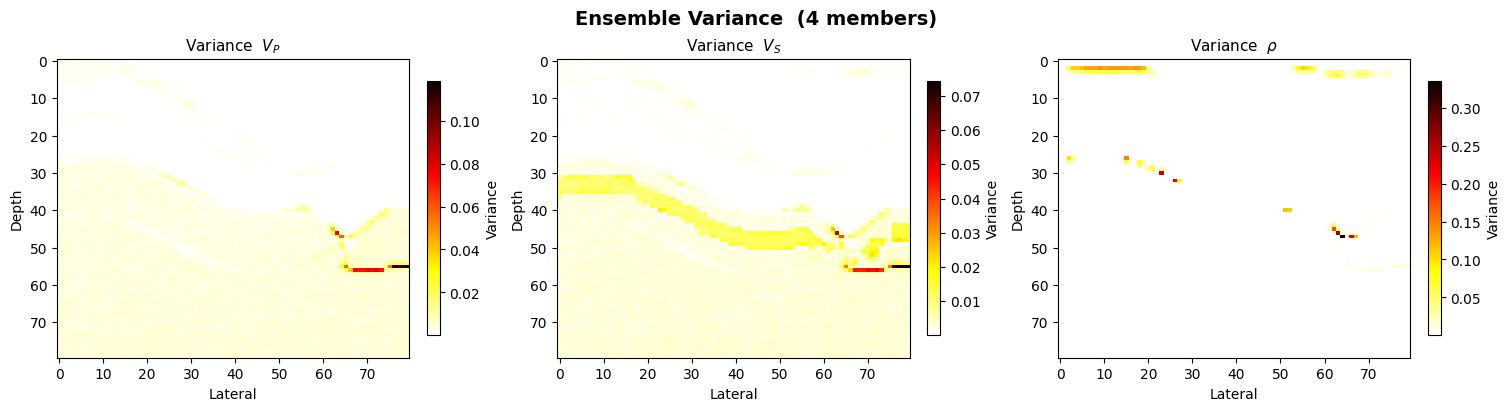

In [21]:
def plot_uncertainty(x_pred):
    var = x_pred.var(dim=0).numpy()  # (3, H, W)
    labels = ['$V_P$', '$V_S$', r'$\rho$']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle(f'Ensemble Variance  ({x_pred.shape[0]} members)', fontsize=14, fontweight='bold')
    for ax, v, lbl in zip(axes, var, labels):
        im = ax.imshow(v, cmap='hot_r', aspect='auto', origin='upper')
        ax.set_title(f'Variance  {lbl}', fontsize=11)
        ax.set_xlabel('Lateral'); ax.set_ylabel('Depth')
        plt.colorbar(im, ax=ax, shrink=0.85, label='Variance')
    plt.show()

plot_uncertainty(x_pred)

## 8 · Quantitative Metrics

In [22]:
def report_metrics(sample_data, x_pred):
    rows = [('vp', '$V_P$'), ('vs', '$V_S$'), ('rho', r'$\rho$')]
    print(f"{'Variable':<8}  {'RMSE':>10}  {'MAE':>10}  {'R²':>8}")
    print('-' * 44)
    for i, (key, lbl) in enumerate(rows):
        gt   = torch.from_numpy(sample_data[f'{key}_true'][0, 0]).float()  # (H, W)
        pred = x_pred[:, i].mean(0)                                         # (H, W)
        rmse = (pred - gt).pow(2).mean().sqrt().item()
        mae  = (pred - gt).abs().mean().item()
        ss_res = (pred - gt).pow(2).sum().item()
        ss_tot = (gt - gt.mean()).pow(2).sum().item()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        print(f'{lbl:<8}  {rmse:>10.2f}  {mae:>10.2f}  {r2:>8.4f}')

report_metrics(sample_data, x_pred)

Variable        RMSE         MAE        R²
--------------------------------------------
$V_P$        2971.52     2854.43  -11.9127
$V_S$        1492.82     1425.58  -10.3163
$\rho$          4.05        3.98  -165.8027


## Summary

| Step | What happened |
|---|---|
| **Input** | Seismic wavefields $v_x, v_z$ (shots × time × receivers) |
| **Model** | Conditional `DiffusionFWINet` trained on elastic wave simulations |
| **Output** | Ensemble of velocity models $(V_P, V_S, \\rho)$ |
| **Uncertainty** | Per-pixel ensemble variance highlights uncertain regions |

**Next steps:**
- Try a different sample with the **Sample** dropdown above
- Increase **Ensembles** for a richer uncertainty estimate
- Install `deepwave` and switch to *Live inference* to run physics-informed DPS

📌 **Upstream example:** `examples/geophysics/diffusion_fwi/` in the [PhysicsNeMo repo](https://github.com/NVIDIA/physicsnemo)